<a href="https://colab.research.google.com/github/MH-mirghaderi/DataScience.course/blob/main/LoanDefaultPrediction_Mirghaderi_(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font face="XB Zar" size=5><div dir=rtl align=center>
We Trust in God
<br>
<font color=yellow size=5>
Mohammad Hossein Mirghaderi
<br>
<font color=red size=5>
Data Scientist Position – Task
<br>
<hr>
<font color= white size=5>
ferrum_company
<br>
<font color= white size=3>
2025/5/31



# Loan Default Prediction
In this notebook, using past loan data and customer information, we aim to implement a machine learning model to predict the risk of loan default by borrowers. By conducting this analysis, lenders will be better equipped to evaluate the creditworthiness of potential borrowers and make informed decisions, leading to improved risk management and reduced loan default rates.

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

##Load Data

In [ ]:
train = pd.read_csv("/content/Training Data.csv")
test = pd.read_csv("/content/Test Data.csv")

In [ ]:
train.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3.0,13.0,0.0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9.0,13.0,0.0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4.0,10.0,0.0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2.0,12.0,1.0
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3.0,14.0,1.0


In [ ]:
test.head()

,ID,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
0,1,7393090,59,19,single,rented,no,Geologist,Malda,West Bengal,4,13
1,2,1215004,25,5,single,rented,no,Firefighter,Jalna,Maharashtra,5,10
2,3,8901342,50,12,single,rented,no,Lawyer,Thane,Maharashtra,9,14
3,4,1944421,49,9,married,rented,yes,Analyst,Latur,Maharashtra,3,12
4,5,13429,25,18,single,rented,yes,Comedian,Berhampore,West Bengal,13,11


In [ ]:
train.shape

(223389, 13)

In [ ]:
test.shape

(28000, 12)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223389 entries, 0 to 223388
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Id                 223389 non-null  int64  
 1   Income             223389 non-null  int64  
 2   Age                223389 non-null  int64  
 3   Experience         223389 non-null  int64  
 4   Married/Single     223389 non-null  object 
 5   House_Ownership    223389 non-null  object 
 6   Car_Ownership      223389 non-null  object 
 7   Profession         223389 non-null  object 
 8   CITY               223389 non-null  object 
 9   STATE              223389 non-null  object 
 10  CURRENT_JOB_YRS    223388 non-null  float64
 11  CURRENT_HOUSE_YRS  223388 non-null  float64
 12  Risk_Flag          223388 non-null  float64
dtypes: float64(3), int64(4), object(6)
memory usage: 22.2+ MB


In [ ]:

# Rename for consistency
test.rename(columns={"ID": "Id"}, inplace=True)

# Encode categorical features
categorical_cols = train.select_dtypes(include="object").columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = test[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    label_encoders[col] = le


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223389 entries, 0 to 223388
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Id                 223389 non-null  int64  
 1   Income             223389 non-null  int64  
 2   Age                223389 non-null  int64  
 3   Experience         223389 non-null  int64  
 4   Married/Single     223389 non-null  int64  
 5   House_Ownership    223389 non-null  int64  
 6   Car_Ownership      223389 non-null  int64  
 7   Profession         223389 non-null  int64  
 8   CITY               223389 non-null  int64  
 9   STATE              223389 non-null  int64  
 10  CURRENT_JOB_YRS    223388 non-null  float64
 11  CURRENT_HOUSE_YRS  223388 non-null  float64
 12  Risk_Flag          223388 non-null  float64
dtypes: float64(3), int64(10)
memory usage: 22.2 MB


In [ ]:
train.describe()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,223389.000000,2.233890e+05,223389.000000,223389.000000,223389.000000,223389.000000,223389.000000,223389.000000,223389.000000,223389.000000,223388.000000,223388.000000,223388.000000
mean,111695.000000,4.996521e+06,49.953234,10.101281,0.897605,1.892054,0.302580,25.323310,158.209504,14.797255,6.341151,11.996128,0.112956
std,64486.993979,2.877858e+06,17.067452,5.996218,0.303168,0.391179,0.459376,14.727967,92.320931,9.378245,3.643970,1.396666,0.316540
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000
25%,55848.000000,2.499276e+06,35.000000,5.000000,1.000000,2.000000,0.000000,13.000000,78.000000,7.000000,4.000000,11.000000,0.000000
50%,111695.000000,5.002101e+06,50.000000,10.000000,1.000000,2.000000,0.000000,26.000000,157.000000,15.000000,6.000000,12.000000,0.000000
75%,167542.000000,7.475587e+06,65.000000,15.000000,1.000000,2.000000,1.000000,38.000000,238.000000,23.000000,9.000000,13.000000,0.000000
max,223389.000000,9.999180e+06,79.000000,20.000000,1.000000,2.000000,1.000000,50.000000,316.000000,29.000000,14.000000,14.000000,1.000000


In [ ]:
# Prepare training and test data
train = train.dropna(subset=["Risk_Flag"])
X_test = test.drop(columns=["Id"])
X = train.drop(columns=["Risk_Flag", "Id"])
y = train["Risk_Flag"]
X_test = test.drop(columns=["Id"])
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Validation
val_preds = model.predict(X_val)
print(classification_report(y_val, val_preds))


              precision    recall  f1-score   support

         0.0       0.99      0.90      0.95     39631
         1.0       0.55      0.94      0.70      5047

    accuracy                           0.91     44678
   macro avg       0.77      0.92      0.82     44678
weighted avg       0.94      0.91      0.92     44678



### Result
Class 0 (No Default Risk)
Precision: 0.99 → Of everyone the model predicted would not default, 99% were correct.

Recall: 0.90 → Among all individuals who are truly low-risk, the model correctly identified 90%.

The model performs exceptionally well in detecting low-risk individuals.

Class 1 (Defaulters)
Precision: 0.55 → Only 55% of those the model predicted as having default risk actually defaulted.

Recall: 0.94 → But it successfully identified 94% of all actual defaulters!

This means the model is very sensitive in detecting high-risk individuals, but the false positive rate is high.

In [ ]:
# Predict test data
test_preds = model.predict(X_test)

# Generate submission
submission = pd.DataFrame({
    "ID": test["Id"],
    "Risk_Flag": test_preds
})
submission.sort_values("ID", inplace=True)

# Save output
submission.to_csv("submission_final.csv", index=False)
submission.head()


,ID,Risk_Flag
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


## Exploratory Data Analysis

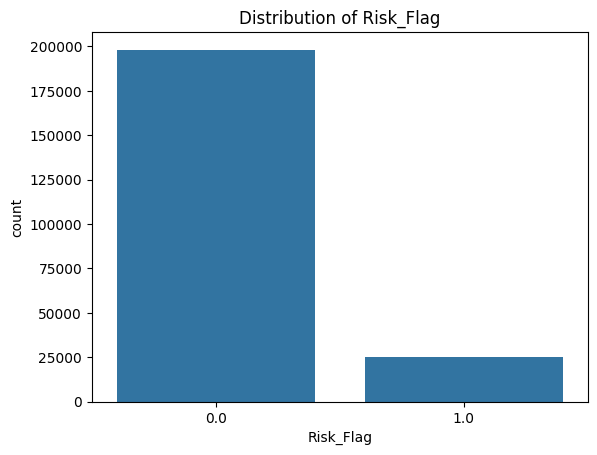

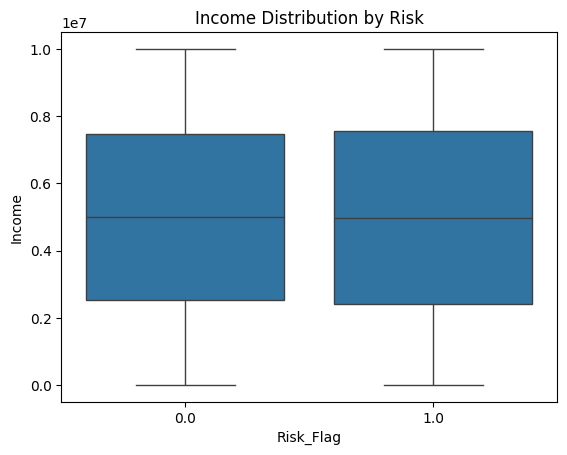

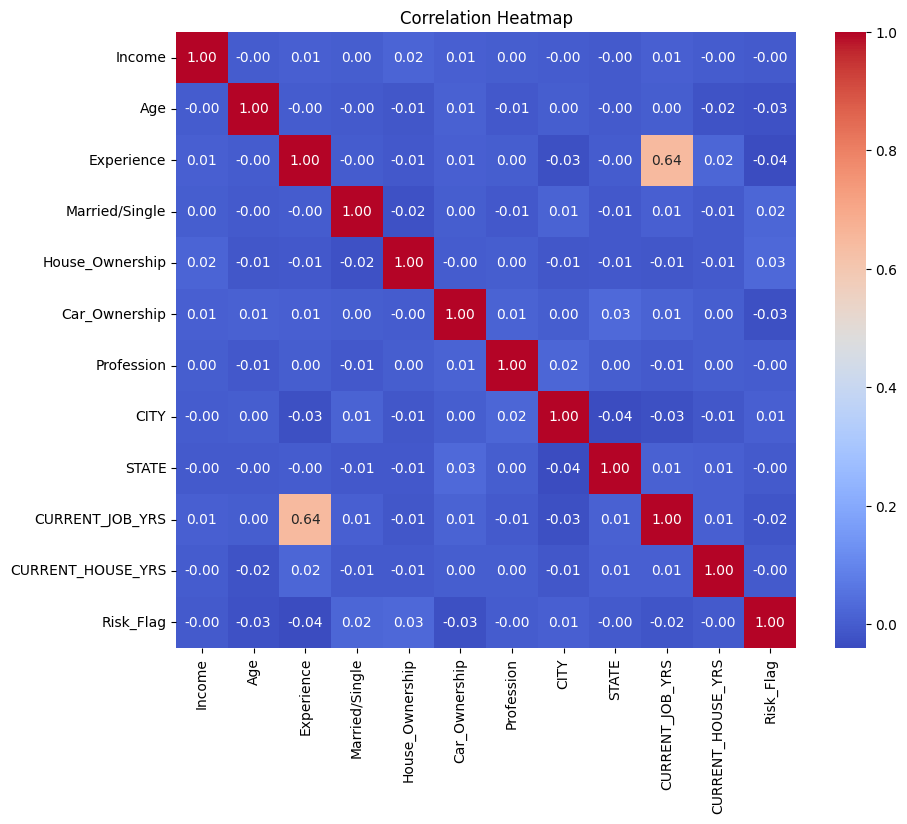

In [ ]:
# Distribution of target variable
sns.countplot(x='Risk_Flag', data=train)
plt.title('Distribution of Risk_Flag')
plt.show()

# Income distribution by Risk Flag
sns.boxplot(x='Risk_Flag', y='Income', data=train)
plt.title('Income Distribution by Risk')
plt.show()

# Correlation heatmap
numeric_cols = train.select_dtypes(include='number').drop(columns=['Id']).columns
plt.figure(figsize=(10,8))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Result
Low Correlation with Target (Risk_Flag):
No feature has a strong linear correlation with the target Risk_Flag.

The highest absolute correlations with Risk_Flag are:

Experience: -0.04

CURRENT_JOB_YRS: -0.02

All others hover around 0.00 to ±0.03, indicating weak or negligible linear relationships.

Moderate Feature Correlation:
The only significant correlation appears between:

Experience and CURRENT_JOB_YRS: 0.64

This is logical since more experienced individuals likely have longer current job tenure.



> No single feature linearly drives the risk of default, which supports the use of non-linear models like Random Forest or XGBoost.



##  Model Development: Logistic Regression & Random Forest

In [ ]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_scores = cross_val_score(logreg, X, y, cv=5, scoring='f1')
print("Logistic Regression F1 Scores:", log_scores)
print("Mean F1:", log_scores.mean())

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_scores = cross_val_score(rf, X, y, cv=10, scoring='f1')
print("Random Forest F1 Scores:", rf_scores)
print("Mean F1:", rf_scores.mean())

# Train final model
rf.fit(X_train, y_train)


Logistic Regression F1 Scores: [0.18998078 0.17795297 0.20860223 0.21797944 0.18173606]
Mean F1: 0.19525029405275837
Random Forest F1 Scores: [0.80146125 0.74922049 0.74512699 0.87634595 0.62956956 0.63393194
 0.73920047 0.65549929 0.71465004 0.44078666]
Mean F1: 0.6985792632320352


RandomForestClassifier(class_weight='balanced', random_state=42)

## Model Evaluation: ROC Curve and Lift Curve

 ROC AUC Score: 0.9566


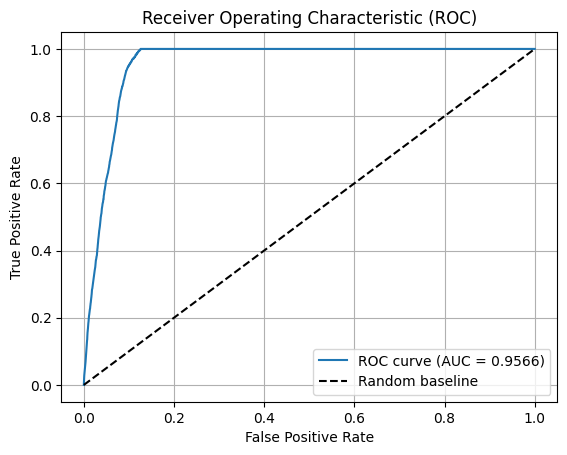

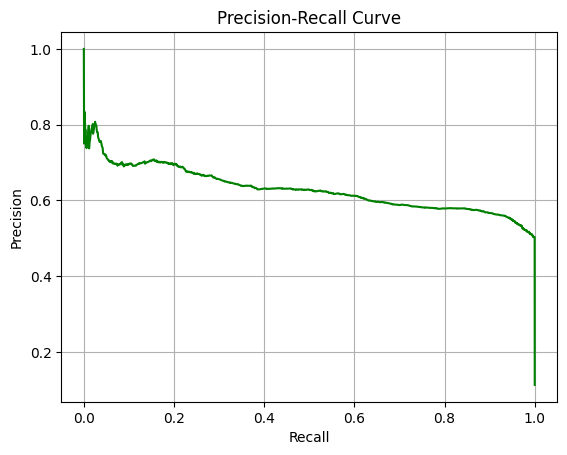

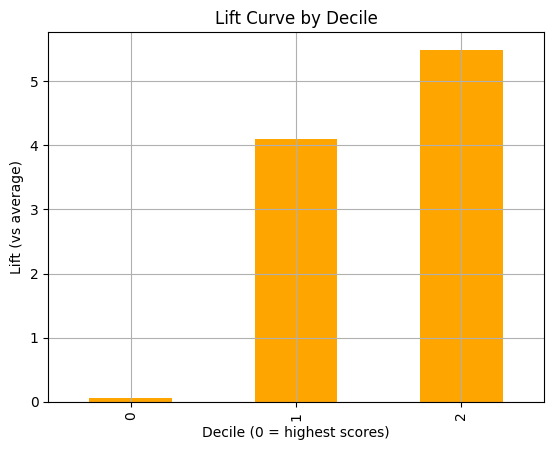

In [ ]:

y_probs = rf.predict_proba(X_val)[:, 1]
# 1. ROC Curve + AUC Score
fpr, tpr, _ = roc_curve(y_val, y_probs)
roc_auc = auc(fpr, tpr)
print(f" ROC AUC Score: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# 2. Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_val, y_probs)
plt.figure()
plt.plot(recall, precision, color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()


# 3. Lift Curve
lift_df = pd.DataFrame({'y_true': y_val, 'y_score': y_probs})
lift_df = lift_df.sort_values(by='y_score', ascending=False)
lift_df['decile'] = pd.qcut(lift_df['y_score'], 10, labels=False, duplicates='drop')

baseline = lift_df['y_true'].mean()
lift = lift_df.groupby('decile')['y_true'].mean() / baseline

plt.figure()
lift.plot(kind='bar', color='orange')
plt.title('Lift Curve by Decile')
plt.xlabel('Decile (0 = highest scores)')
plt.ylabel('Lift (vs average)')
plt.grid()
plt.show()


### ROC AUC Score: 0.9566

###Result
1. ROC Curve
AUC = 0.9566, indicating excellent discriminatory power between class 0 (non-defaulters) and class 1 (defaulters).

The curve is close to the top-left corner, which is ideal.

The False Positive Rate (FPR) is kept low while achieving a high True Positive Rate (TPR).


2. Precision-Recall Curve
Between Recall = 0.0 to 0.6, Precision stays relatively strong (~0.6 to 0.8).
As Recall increases, Precision gradually drops, which is expected behavior.

Some noise or fluctuation appears at the leftmost part, likely due to class imbalance or scoring noise.


3. Lift Curve by Decile

Deciles 1 and 2 show the highest lift:

Decile 1: ~4.1× better than average

Decile 2: ~5.5× better than average

Decile 0 (supposedly highest-risk scores) shows very low lift, indicating possible prediction noise or misranking.



##XGBOOST

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=5,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_val)
y_probs = xgb_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
f1 = f1_score(y_val, y_pred)
report = classification_report(y_val, y_pred)

print(f" ROC AUC Score: {roc_auc:.4f}")
print(f" F1-Score (Class 1): {f1:.4f}")
print(report)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:38:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 ROC AUC Score: 0.9289
 F1-Score (Class 1): 0.6325
              precision    recall  f1-score   support

         0.0       0.97      0.92      0.94     39631
         1.0       0.55      0.75      0.63      5047

    accuracy                           0.90     44678
   macro avg       0.76      0.83      0.79     44678
weighted avg       0.92      0.90      0.91     44678



## H-Measure
H-measure is not available in sklearn, typically used via R packages.